In [1]:
OURS_COLOR = "#d62728"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 120,
    "mathtext.fontset": "stix",
    "font.family": "serif",
})

OURS_COLOR = "#d62728"

RESULTS_DIR_CANDIDATES = [
    Path("."),
    Path("./Results"),
    Path("../Results"),
]

def load_results_csv(filename: str) -> pd.DataFrame:
    for base in RESULTS_DIR_CANDIDATES:
        path = base / filename
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find {filename}. Checked: {[str((b / filename).resolve()) for b in RESULTS_DIR_CANDIDATES]}"
    )

def add_msnr_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    snr_cols = sorted(
        [c for c in df.columns if c.startswith("SNR_")],
        key=lambda x: int(x.split("_")[1])
    )
    if not snr_cols:
        raise ValueError("No component SNR columns (SNR_1, SNR_2, ...) were found.")
    df["mSNR"] = df[snr_cols].mean(axis=1)
    return df

DISTRIBUTION_ORDER = [
    "gaussian",
    "uniform",
    "laplace",
    "rademacher",
    "student_t_df5",
]

DISTRIBUTION_LABELS = {
    "gaussian":        r"$\mathcal{N}(0,1)$",
    "uniform":         r"$\mathcal{U}(-\sqrt{3},\sqrt{3})$",
    "laplace":         r"$\mathrm{Laplace}(0,1/\sqrt{2})$",
    "rademacher":      r"$\mathrm{Rad}(\pm 1)$",
    "student_t_df5":   r"$\sqrt{3/5}\,t_5$",
}

/tmp/ipykernel_1456458/2728158845.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


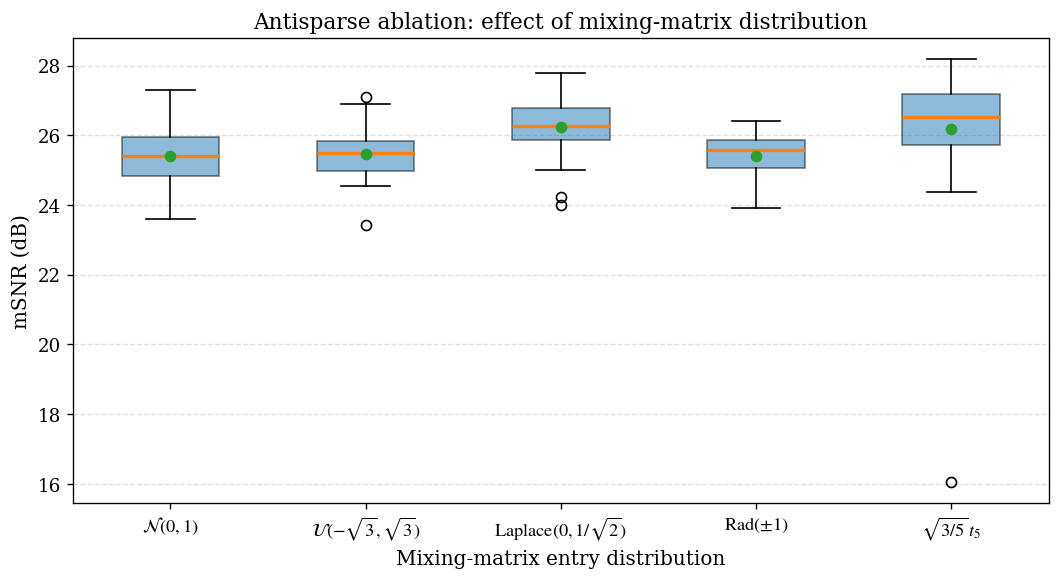

In [2]:
df = load_results_csv("predictive_bss_ablation_mixing_distribution_antisparse_10by5_results.csv")
df = add_msnr_column(df)

data = [
    df.loc[df["mixing_distribution"] == dist, "mSNR"].values
    for dist in DISTRIBUTION_ORDER
]
labels = [DISTRIBUTION_LABELS[d] for d in DISTRIBUTION_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanline=False,
)

for box in bp["boxes"]:
    box.set(alpha=0.5)
for median in bp["medians"]:
    median.set(linewidth=2)
for mean in bp["means"]:
    mean.set(marker="o", markersize=6)

ax.set_xlabel("Mixing-matrix entry distribution")
ax.set_ylabel("mSNR (dB)")
ax.set_title("Antisparse ablation: effect of mixing-matrix distribution")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figures/antisparse_ablation_mixing_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1456458/244789317.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


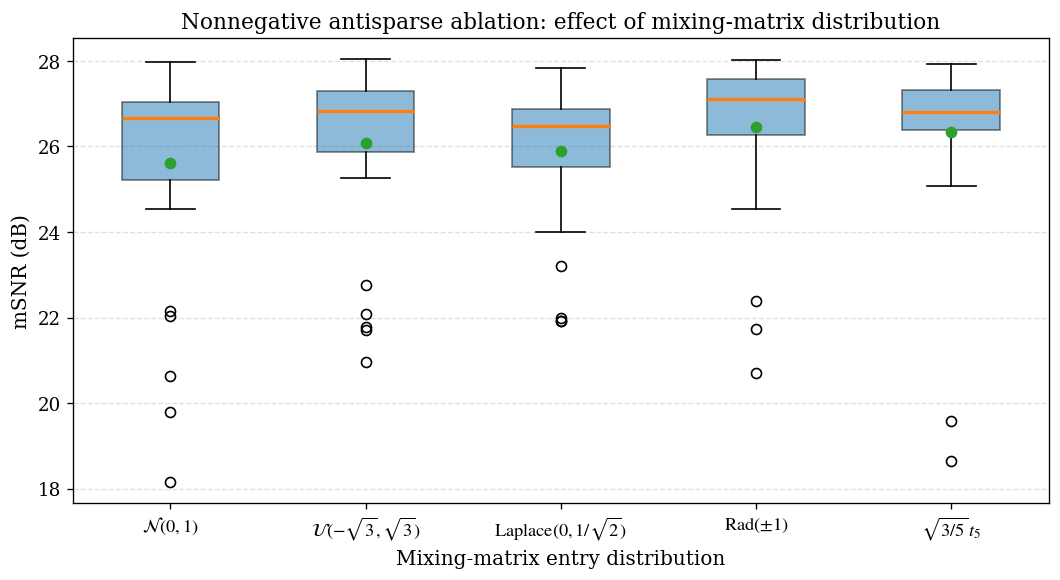

In [3]:
df = load_results_csv("predictive_bss_ablation_mixing_distribution_nnantisparse_10by5_results.csv")
df = add_msnr_column(df)

data = [
    df.loc[df["mixing_distribution"] == dist, "mSNR"].values
    for dist in DISTRIBUTION_ORDER
]
labels = [DISTRIBUTION_LABELS[d] for d in DISTRIBUTION_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanline=False,
)

for box in bp["boxes"]:
    box.set(alpha=0.5)
for median in bp["medians"]:
    median.set(linewidth=2)
for mean in bp["means"]:
    mean.set(marker="o", markersize=6)

ax.set_xlabel("Mixing-matrix entry distribution")
ax.set_ylabel("mSNR (dB)")
ax.set_title("Nonnegative antisparse ablation: effect of mixing-matrix distribution")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figures/nnantisparse_ablation_mixing_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

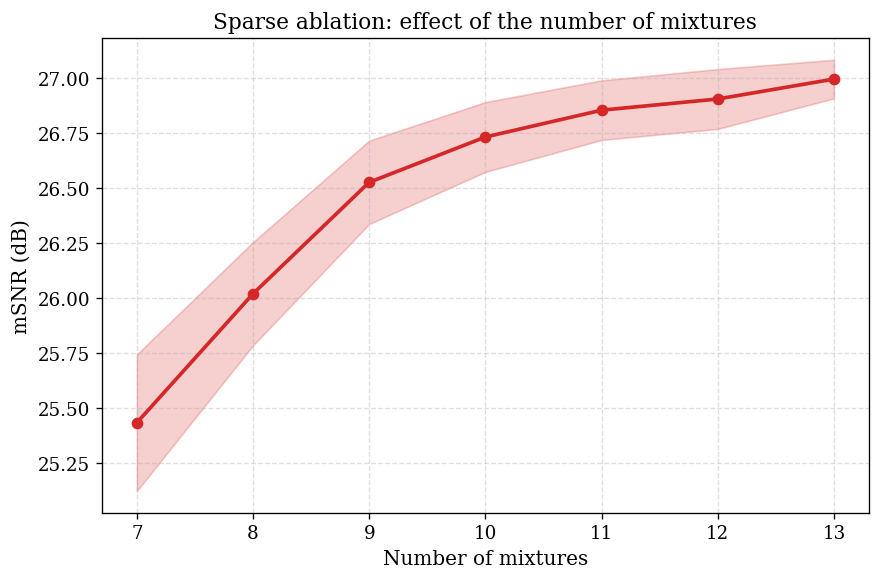

In [4]:
df = load_results_csv("predictive_bss_ablation_number_of_mixtures_sparse_results.csv")
df = add_msnr_column(df)

summary = (
    df.groupby("n_mixtures")["mSNR"]
      .agg(["mean", "std", "count"])
      .reset_index()
      .sort_values("n_mixtures")
)
summary["se"] = summary["std"] / np.sqrt(summary["count"])

x = summary["n_mixtures"].to_numpy()
y = summary["mean"].to_numpy()
se = summary["se"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(x, y, marker="o", linewidth=2.2, color=OURS_COLOR)
ax.fill_between(x, y - se, y + se, color=OURS_COLOR, alpha=0.22)

ax.set_xlabel("Number of mixtures")
ax.set_ylabel("mSNR (dB)")
ax.set_title("Sparse ablation: effect of the number of mixtures")
ax.set_xticks(x)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figures/sparse_ablation_number_of_mixtures.pdf", format="pdf", bbox_inches="tight")
plt.show()

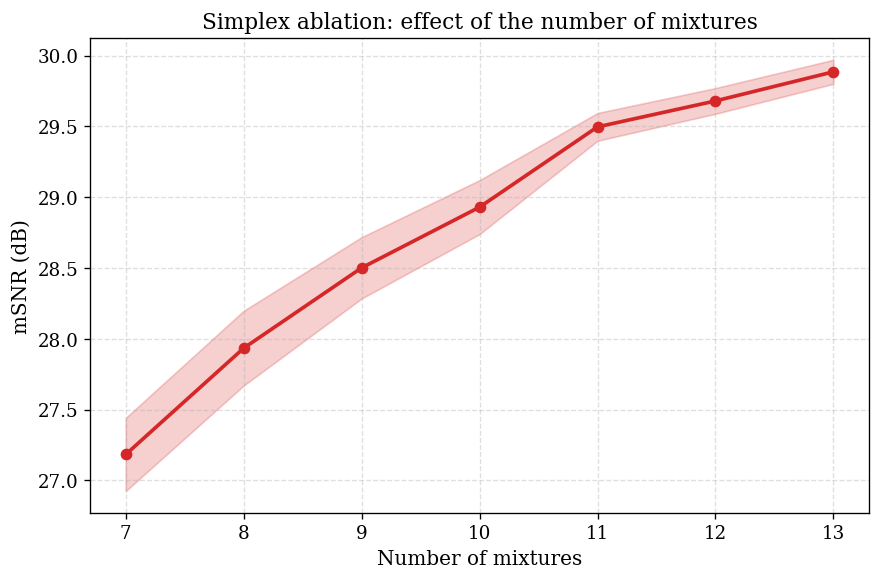

In [5]:
df = load_results_csv("predictive_bss_ablation_number_of_mixtures_simplex_results.csv")
df = add_msnr_column(df)

summary = (
    df.groupby("n_mixtures")["mSNR"]
      .agg(["mean", "std", "count"])
      .reset_index()
      .sort_values("n_mixtures")
)
summary["se"] = summary["std"] / np.sqrt(summary["count"])

x = summary["n_mixtures"].to_numpy()
y = summary["mean"].to_numpy()
se = summary["se"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(x, y, marker="o", linewidth=2.2, color=OURS_COLOR)
ax.fill_between(x, y - se, y + se, color=OURS_COLOR, alpha=0.22)

ax.set_xlabel("Number of mixtures")
ax.set_ylabel("mSNR (dB)")
ax.set_title("Simplex ablation: effect of the number of mixtures")
ax.set_xticks(x)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figures/simplex_ablation_number_of_mixtures.pdf", format="pdf", bbox_inches="tight")
plt.show()